In [1]:
import astropy.units as u
import astropy.coordinates as apycoords
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def galcen_cyl(ra, dec, distance, pmra, pmdec, radial_velocity):
    """
    Converts ICRS ra (deg), dec (deg), parallax (mas), pmra (mas/yr),
    pmdec (mas/yr), and radial velocity (km/s) to Galactocentric cylindrical coordinates
    rho (kpc), phi (deg), z (pc), v_rho (km/s), v_phi (km/s), v_z (km/s)

    LEFT-HANDED

    Args:
        ra (array-like): Right ascension in degrees
        dec (array-like): Declination in degrees
        distance (array-like): Distance in parsecs
        pmra (array-like): Proper motion in right ascension (mas/yr)
        pmdec (array-like): Proper motion in declination (mas/yr)
        radial_velocity (array-like): Radial velocity in km/s

    Returns:
        numpy.ndarray: (n x 6) array of galactocentric cylindrical coordinates


    """

    c = apycoords.SkyCoord(
        ra=ra * u.deg,
        dec=dec * u.deg,
        distance=distance * u.pc,
        pm_ra_cosdec=pmra * u.mas / u.yr,
        pm_dec=pmdec * u.mas / u.yr,
        radial_velocity=radial_velocity * u.km / u.s,
        frame="icrs",
    )

    v_sun = apycoords.CartesianDifferential([11.1, 245.0, 7.25] * u.km / u.s)
    gc_frame = apycoords.Galactocentric(
        galcen_distance=8.25 * u.kpc, z_sun=20.8 * u.pc, galcen_v_sun=v_sun
    )

    gc = c.transform_to(gc_frame)
    gc.representation_type = "cylindrical"

    cyl_coord = np.vstack(
        [
            gc.rho.to(u.kpc).value,
            180 - gc.phi.degree,  # 180 - PHI ASTROPY CONVENTION
            gc.z.to(u.pc).value,
            gc.d_rho.to(u.km / u.s).value,
            -(gc.d_phi * gc.rho)
            .to(u.km / u.s, equivalencies=u.dimensionless_angles())
            .value,  # FLIPPED SIGN FROM ASTROPY CONVENTION
            gc.d_z.to(u.km / u.s).value,
        ]
    ).T

    return cyl_coord


def skycoord_cylvel_to_dvT(ra, dec, parallax, pmra, pmdec, v_rho, v_phi, v_z):

    v_sun = apycoords.CartesianDifferential([11.1, 245.0, 7.25] * u.km / u.s)

    gc_frame = apycoords.Galactocentric(
        galcen_distance=8.25 * u.kpc, z_sun=20.8 * u.pc, galcen_v_sun=v_sun
    )

    c = apycoords.SkyCoord(
        ra=ra * u.deg,
        dec=dec * u.deg,
        distance=(1000.0 / parallax) * u.pc,
        frame="icrs",
    )

    gc = c.transform_to(gc_frame)

    cyl = gc.represent_as(apycoords.CylindricalRepresentation)
    phi = cyl.phi

    v_rho = np.asarray(v_rho) * u.km / u.s
    v_phi = -np.asarray(v_phi) * u.km / u.s
    v_z = np.asarray(v_z) * u.km / u.s

    vx = v_rho * np.cos(phi) - v_phi * np.sin(phi)
    vy = v_rho * np.sin(phi) + v_phi * np.cos(phi)
    vz = v_z

    gc_vel = apycoords.Galactocentric(
        x=gc.x,
        y=gc.y,
        z=gc.z,
        v_x=vx,
        v_y=vy,
        v_z=vz,
        galcen_distance=8.25 * u.kpc,
        z_sun=20.8 * u.pc,
        galcen_v_sun=v_sun,
    )

    icrs = apycoords.SkyCoord(gc_vel).transform_to(apycoords.ICRS())

    vra = 4.74047 * pmra / parallax
    vdec = 4.74047 * pmdec / parallax

    proj_pmra = icrs.pm_ra_cosdec.to(u.mas / u.yr).value
    proj_pmdec = icrs.pm_dec.to(u.mas / u.yr).value
    proj_vra = (
        (icrs.pm_ra_cosdec * icrs.distance)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )
    proj_vdec = (
        (icrs.pm_dec * icrs.distance)
        .to(u.km / u.s, equivalencies=u.dimensionless_angles())
        .value
    )
    proj_vrad = icrs.radial_velocity.to(u.km / u.s).value

    delta_vra = vra - proj_vra
    delta_vdec = vdec - proj_vdec
    delta_vT = np.sqrt(delta_vra**2 + delta_vdec**2)

    return np.vstack(
        [vra, vdec, proj_vra, proj_vdec, proj_vrad, delta_vra, delta_vdec, delta_vT]
    ).T

In [16]:
clu_params = pd.read_csv("/Users/sharifi/Documents/escapees/data/clu_params.csv")

In [17]:
clu_name = "Melotte_22"
clu = clu_params.loc[clu_params.name == clu_name].reset_index(drop=True).copy()

In [ ]:
cyl_coord = galcen_cyl(
    clu.ra.values[0],
    clu.dec.values[0],
    1000 / clu.median_member_parallax.values[0],
    clu.pmra.values[0],
    clu.pmdec.values[0],
    clu.median_member_RV.values[0],
)
cyl_coord = cyl_coord.flatten()

In [26]:
skycoord_cylvel_to_dvT(
    clu.ra.values[0],
    clu.dec.values[0],
    clu.median_member_parallax.values[0],
    clu.pmra.values[0],
    clu.pmdec.values[0],
    cyl_coord[3],
    cyl_coord[4],
    cyl_coord[5],
)

array([[ 1.28576068e+01, -2.92888625e+01,  1.28576081e+01,
        -2.92888654e+01,  5.43553300e+00, -1.25724441e-06,
         2.86392793e-06,  3.12773827e-06]])

In [31]:
4.74047 * clu.pmdec / clu.median_member_parallax

0   -29.288863
dtype: float64

In [ ]:
vra, vdec, proj_vra, proj_vdec, proj_vrad, delta_vra, delta_vdec, delta_vT

In [ ]:
#    rho (kpc), 180 - phi (deg), z (pc),
#    v_rho (km/s), - v_phi (km/s), v_z (km/s)

<Axes: >

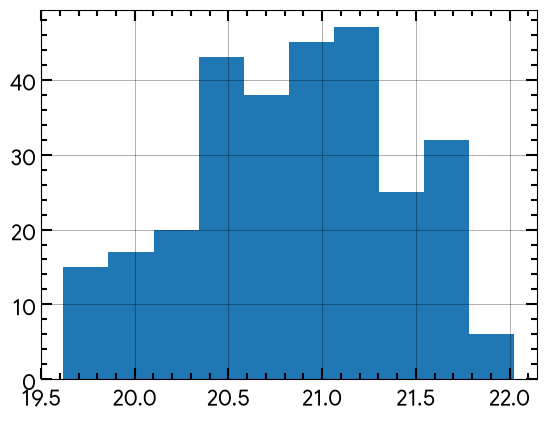

In [40]:
((1000 * clu_params.z_cyl) - clu_params.z).hist()